In [1]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils.data_loader import DataLoader
from src.preprocessing.data_cleaner import DataCleaner
from src.eda.analyzer import EDAAnalyzer
from src.feature_engineering.preprocessor import FeatureEngineer

INFO:src.preprocessing.data_cleaner:DataCleaner initialized.
c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio\src\preprocessing\data_cleaner.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col].fillna(fill_val, inplace = True)
c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio\src\preprocessing\data_cleaner.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work b

CLEANING
    Age   Salary City Purchased
0  25.0  50000.0   NY        No
1  30.0  60000.0   LA       Yes
2  37.5  55000.0   NY       Yes
3  45.0  57500.0   SF        No
4  67.5  70000.0   LA       Yes

EDA
        count     mean          std      min      25%      50%      75%  \
Age       5.0     41.0    16.639561     25.0     30.0     37.5     45.0   
Salary    5.0  58500.0  7416.198487  50000.0  55000.0  57500.0  60000.0   

            max  
Age        67.5  
Salary  70000.0  


INFO:src.eda.analyzer:Generated 2 distribution plots.


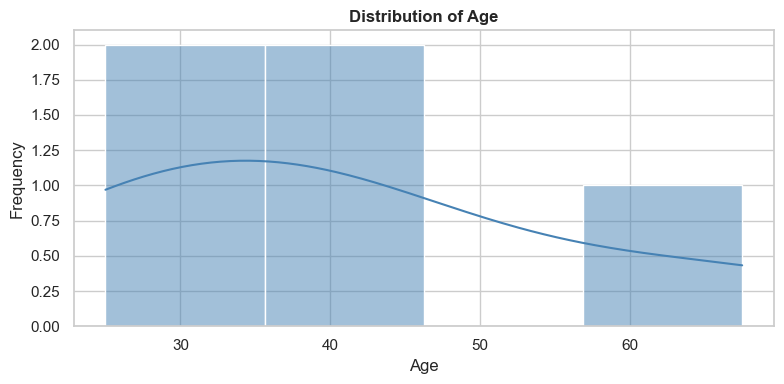

In [3]:
# Create a dummy dataset
data = {
    'Age': [25, 30, np.nan, 45, 120], 
    'Salary': [50000, 60000, 55000, np.nan, 70000],
    'City': ['NY', 'LA', 'NY', 'SF', 'LA'],
    'Purchased': ['No', 'Yes', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(data)

print("CLEANING")
cleaner = DataCleaner(df)
cleaner.handle_missing_values(strategy='median', columns=['Age', 'Salary'])
cleaner.auto_handle_outliers()
cleaned_df = cleaner.get_cleaned_dataFrame()
print(cleaned_df.head())

print("\nEDA")
analyzer = EDAAnalyzer(cleaned_df)
print(analyzer.get_summary_statistics())
figs = analyzer.plot_numerical_distributions()
figs[0]

In [4]:
print("\nFEATURE ENGINEERING")
engineer = FeatureEngineer(cleaned_df, target_column='Purchased')
engineer.apply_encoding()
engineer.apply_scaling()
X, y = engineer.get_processed_dataframe()
print(X.head())

INFO:src.feature_engineering.preprocessor:FeatureEngineer initialized
INFO:src.feature_engineering.preprocessor:Applied Label Encoding to target: Purchased
INFO:src.feature_engineering.preprocessor:Applied One-Hot Encoding to: ['City']
INFO:src.feature_engineering.preprocessor:Applied Standard Scaling to 2 numerical features.



FEATURE ENGINEERING
        Age    Salary  City_NY  City_SF
0 -1.075061 -1.281423     True    False
1 -0.739104  0.226134    False    False
2 -0.235170 -0.527645     True    False
3  0.268765 -0.150756    False     True
4  1.780570  1.733690    False    False
